In [1]:
## CNNs) are specifically designed to analyze and interpret images.
    # The goal is to assign a label to an image based on its content.

## How CNNs Work for Image Classification?
    # The process of image classification below stages execute:
        # Preprocessing the Image: Images need to be preprocessed before feeding them into the CNN.This includes resizing, normalizing and sometimes augmenting images to make the model more robust and reduce overfitting.
        # Feature Extraction: CNNs automatically detect features from images, starting with simple features like edges and progressing to more complex patterns like objects or faces as we go deeper into the network.
        # Classification: After extracting features, the fully connected layers use the learned information to classify the image. Based on the features detected, the model assigns the image to one of the predefined categories.

In [2]:
# Implementation of Image Classification using CNN

In [6]:

# Note: ModuleNotFoundError: No module named 'tensorflow'(Python can't find the TensorFlow library in your current environment)
# Install TensorFlow -->Open your terminal: run 'pip install tensorflow'--> Re-start Anaconda
# Verify Installation
print(tf.__version__)

# Importing Libraries
import tensorflow as tf # Using Tensorflow libraries for building, training of the model.
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt # using Matplotlib libraries for visualizing and validation accuracy of the model.



2.20.0-rc0


In [7]:
# Downloading and Preparing the Dataset
    # load the CIFAR-10 dataset and preprocess it. It consists of 60,000 32x32 color images across 10 categories.
        # Scaling: We scale the image pixel values from [0, 255] to [0, 1] by dividing by 255.
        # One-hot encoding: Converts the labels (0-9) into a one-hot vector (e.g., for label 2: [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]).

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

num_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test  = tf.keras.utils.to_categorical(y_test , num_classes)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 196s 1us/step


In [8]:
# Building the CNN Model
    # define the CNN architecture and start with convolutional layers followed by max-pooling layers, flatten the output and then feed it into fully connected layers.
         # Flatten Layer: Converts the 2D matrix into a 1D vector for the dense layers.
         # Dense Layers: Fully connected layers used for decision making, with the final layer using softmax activation to predict probabilities.

model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

C:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compiling and Training the Model
    # compile the model by defining the optimizer, loss function and evaluation metric, followed by training. Adam optimizer is used as it adjusts the learning rate during training.

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=2)

Epoch 1/15
625/625 - 45s - 72ms/step - accuracy: 0.4374 - loss: 1.5501 - val_accuracy: 0.5270 - val_loss: 1.3239
Epoch 2/15
625/625 - 36s - 58ms/step - accuracy: 0.5984 - loss: 1.1294 - val_accuracy: 0.6091 - val_loss: 1.1089
Epoch 3/15
625/625 - 32s - 52ms/step - accuracy: 0.6613 - loss: 0.9659 - val_accuracy: 0.6580 - val_loss: 0.9980
Epoch 4/15
625/625 - 33s - 53ms/step - accuracy: 0.7010 - loss: 0.8522 - val_accuracy: 0.6594 - val_loss: 0.9873
Epoch 5/15
625/625 - 39s - 62ms/step - accuracy: 0.7304 - loss: 0.7693 - val_accuracy: 0.7008 - val_loss: 0.8805
Epoch 6/15
625/625 - 32s - 52ms/step - accuracy: 0.7548 - loss: 0.6974 - val_accuracy: 0.7186 - val_loss: 0.8276
Epoch 7/15
625/625 - 33s - 52ms/step - accuracy: 0.7803 - loss: 0.6308 - val_accuracy: 0.7256 - val_loss: 0.8299
Epoch 8/15
625/625 - 42s - 67ms/step - accuracy: 0.8006 - loss: 0.5692 - val_accuracy: 0.7281 - val_loss: 0.8184
Epoch 9/15
625/625 - 32s - 52ms/step - accuracy: 0.8194 - loss: 0.5163 - val_accuracy: 0.7165 - 

In [10]:
# Evaluating the Model
    #  we evaluate the model on the test dataset to check how well it performs on unseen data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"Test accuracy = {test_acc:.3f}")

Test accuracy = 0.707


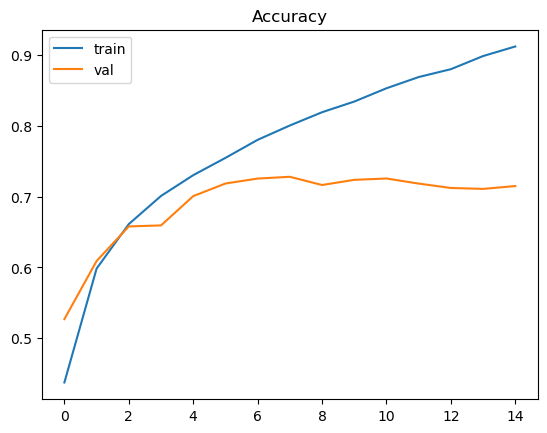

In [11]:
# Plotting of Accuracy Curves
    # visualize the training and validation accuracy during training using matplotlib.

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title('Accuracy')
plt.show()

In [12]:
# Benefits of Using CNNs for Image Classification
    # Automatic Feature Learning: CNNs automatically learn relevant features from images, reducing the need for manual feature extraction and making them more adaptable to different tasks.
    # Translation Invariance: They can recognize objects in images regardless of their position making them more robust to changes in image orientation.
    # Efficiency: Pooling layers help reduce the image's size making the model more computationally efficient while retaining key features.
    # Scalability: They can handle large datasets effectively, as they can process high volumes of data and continue improving with more examples.